<a href="https://colab.research.google.com/github/lauravfonseca/PeopleAnalytics_citi26/blob/main/Representatividade_feminina_por_%C3%81rea_do_CITi_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install pandas matplotlib openpyxl

In [14]:
!pip install gender-guesser

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell I8 is marked as a date but the serial value 14112505400.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


,Total,Mulheres,Porcentagem (%)
Área,,,
Gente e Gestão,4,4,100.0
Marketing,4,4,100.0
Produto,11,8,72.7
Dados,11,4,36.4
Comercial,4,1,25.0
Desenvolvimento,22,5,22.7
Diretoria,5,1,20.0


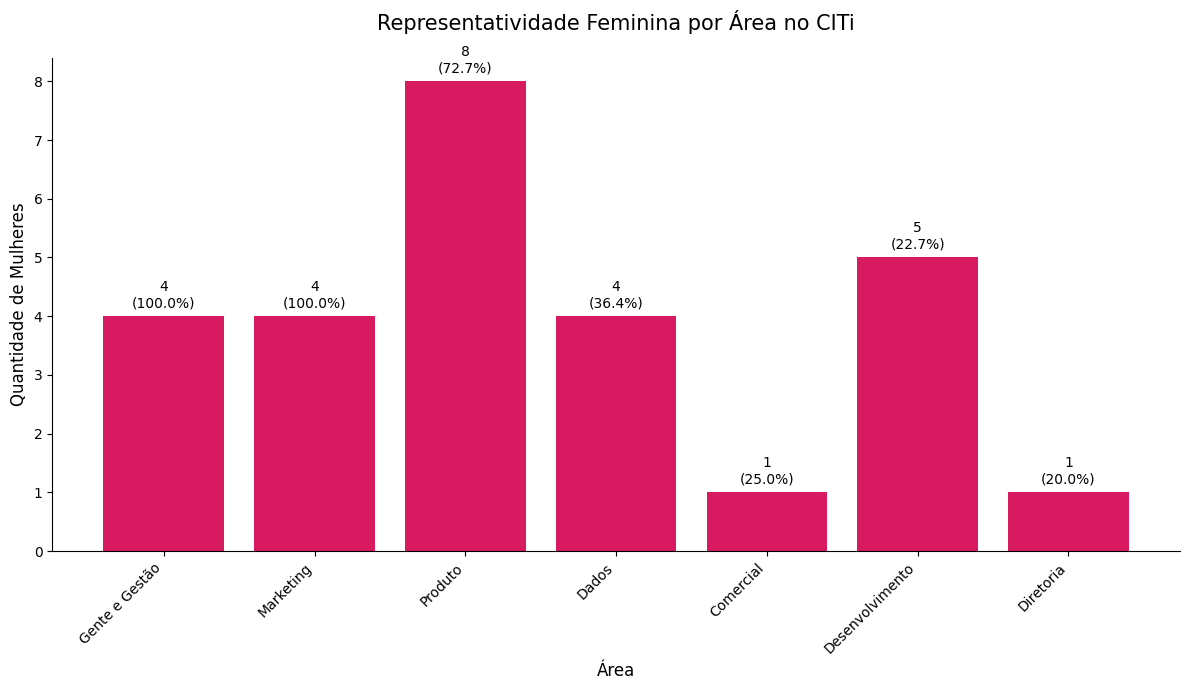

In [15]:
!pip install gender-guesser -q

import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import gender_guesser.detector as gender

def classificar_genero(nome_completo):
    primeiro_nome = str(nome_completo).split()[0]
    primeiro_nome = ''.join(c for c in unicodedata.normalize('NFD', primeiro_nome) if unicodedata.category(c) != 'Mn').capitalize()

    excecoes_br = {
        'Adson': 'male', 'Arthur': 'male', 'Bruno': 'male', 'Cauan': 'male',
        'Daniel': 'male', 'Danilo': 'male', 'Davi': 'male', 'Fabio': 'male',
        'Felipe': 'male', 'Francisco': 'male', 'Gabriel': 'male', 'Guilherme': 'male',
        'Gustavo': 'male', 'Henrique': 'male', 'Joao': 'male', 'Leonardo': 'male',
        'Lucas': 'male', 'Luiz': 'male', 'Marcos': 'male', 'Marcus': 'male',
        'Matheus': 'male', 'Mateus': 'male', 'Pedro': 'male', 'Rafael': 'male',
        'Romero': 'male', 'Theo': 'male', 'Tiago': 'male', 'Victor': 'male',
        'Yuri': 'male', 'Lais': 'female'
    }

    previsao = excecoes_br.get(primeiro_nome) or d.get_gender(primeiro_nome)

    if previsao in ['female', 'mostly_female']:
        return 'Feminino'
    elif previsao in ['male', 'mostly_male']:
        return 'Masculino'
    return 'Não Identificado'

# Configuração e Leitura de Dados
caminho_do_arquivo = '/content/drive/MyDrive/Cópia de CITiPessoas.xlsx'
df = pd.read_excel(caminho_do_arquivo)

# Processamento de Gênero
d = gender.Detector()
col_nome = df.columns[df.columns.str.contains('Nome Completo')][0]
df['Gênero'] = df[col_nome].apply(classificar_genero)

# Limpeza e Mapeamento de Cargos
df = df.rename(columns={'Unnamed: 0': 'Cargo'})
df['Cargo'] = df['Cargo'].astype(str).str.strip()

mapeamento_areas = {
    # Desenvolvimento
    'Pessoa Desenvolvedora': 'Desenvolvimento', 'Analista de Software': 'Desenvolvimento', 'Gerente de Software': 'Desenvolvimento', 'Líder de Desenvolvimento': 'Desenvolvimento',

    # Dados
    'Analista de Dados': 'Dados', 'Gerente de Dados': 'Dados', 'Especialista em Dados': 'Dados', 'Líder de Dados': 'Dados',

    # Produto
    'UX/UI Designer': 'Produto', 'UX/Ui Designer': 'Produto', 'Designer Tech Lead': 'Produto', 'Líder de Design': 'Produto', 'Gerente de Produto': 'Produto',

    # Comercial
    'Gerente Comercial': 'Comercial', 'Gerente de Contas': 'Comercial',

    # Marketing
    'Analista de Marketing': 'Marketing', 'Analista de Makerting': 'Marketing', 'Especialista de Marketing': 'Marketing', 'Gerente de Marketing': 'Marketing',

    # Gente e Gestão
    'Consultora Gente e Gestão': 'Gente e Gestão', 'Especialista de Pessoas': 'Gente e Gestão', 'Especialista em Cultura': 'Gente e Gestão', 'Especialista Financeiro': 'Gente e Gestão',

    # Diretoria
    'Diretor Institucional (CEO)': 'Diretoria', 'Diretor de Negócios (CRO)': 'Diretoria', 'Diretora de Operações (COO)': 'Diretoria', 'Diretor de Soluções (CTO)': 'Diretoria', 'Diretor de Soluções  (CTO)': 'Diretoria', 'Gerente Institucional': 'Diretoria'
}

df['Área'] = df['Cargo'].map(mapeamento_areas)
df_valido = df.dropna(subset=['Área'])

# Agrupamento e Métricas
total_area = df_valido.groupby('Área').size()
mulheres_area = df_valido[df_valido['Gênero'] == 'Feminino'].groupby('Área').size()

resumo = pd.DataFrame({'Total': total_area, 'Mulheres': mulheres_area}).fillna(0)
resumo['Porcentagem (%)'] = (resumo['Mulheres'] / resumo['Total']) * 100
resumo = resumo.sort_values(by='Porcentagem (%)', ascending=False)

display(resumo.round(1))

# Visualização
plt.figure(figsize=(12, 7))
barras = plt.bar(resumo.index, resumo['Mulheres'], color='#D81B60')

for i, barra in enumerate(barras):
    altura = barra.get_height()
    pct = resumo['Porcentagem (%)'].iloc[i]
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
             f'{int(altura)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.title('Representatividade Feminina por Área no CITi', fontsize=15, pad=20)
plt.xlabel('Área', fontsize=12)
plt.ylabel('Quantidade de Mulheres', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell I8 is marked as a date but the serial value 14112505400.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


,Total,Mulheres,% Mulheres,Homens,% Homens
Área,,,,,
Gente e Gestão,4,4,100.0,0.0,0.0
Marketing,4,4,100.0,0.0,0.0
Produto,11,8,72.7,2.0,18.2
Dados,11,4,36.4,7.0,63.6
Comercial,4,1,25.0,3.0,75.0
Desenvolvimento,22,5,22.7,17.0,77.3
Diretoria,5,1,20.0,4.0,80.0


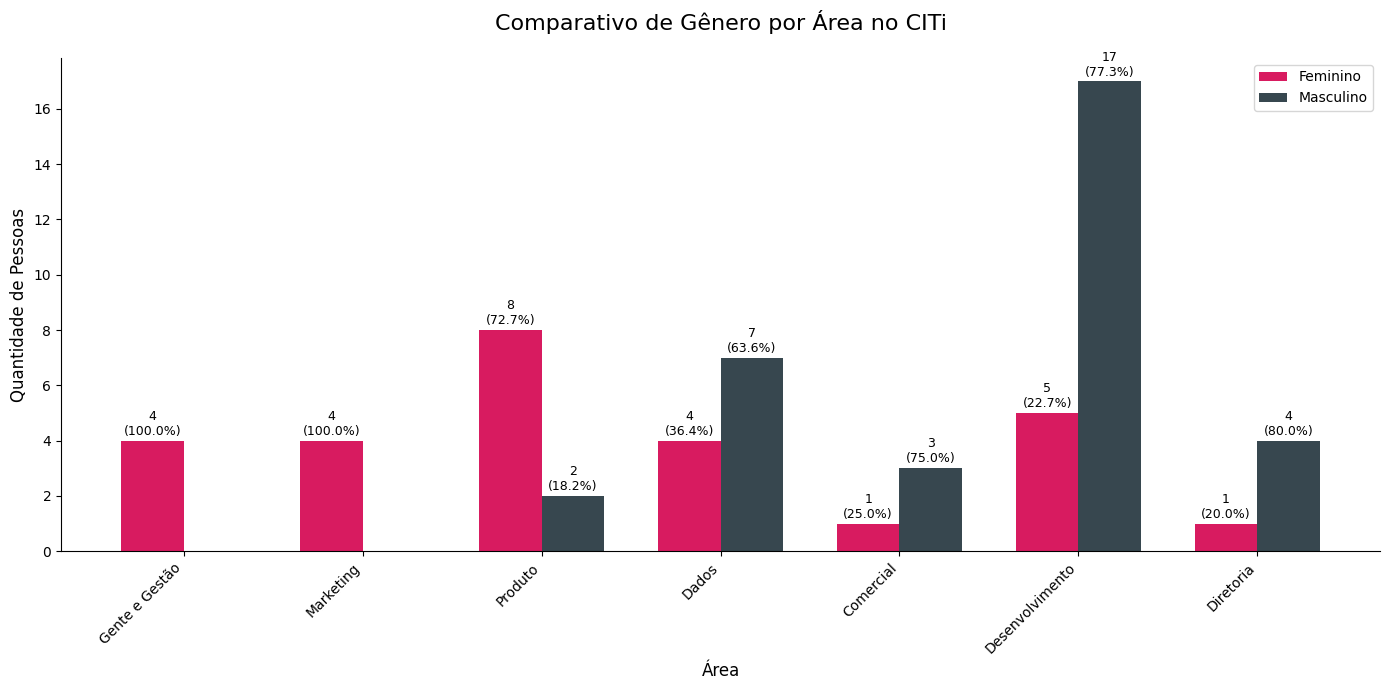

In [16]:
!pip install gender-guesser -q

import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gender_guesser.detector as gender

def classificar_genero(nome_completo):
    primeiro_nome = str(nome_completo).split()[0]
    primeiro_nome = ''.join(c for c in unicodedata.normalize('NFD', primeiro_nome) if unicodedata.category(c) != 'Mn').capitalize()

    excecoes_br = {
        'Adson': 'male', 'Arthur': 'male', 'Bruno': 'male', 'Cauan': 'male',
        'Daniel': 'male', 'Danilo': 'male', 'Davi': 'male', 'Fabio': 'male',
        'Felipe': 'male', 'Francisco': 'male', 'Gabriel': 'male', 'Guilherme': 'male',
        'Gustavo': 'male', 'Henrique': 'male', 'Joao': 'male', 'Leonardo': 'male',
        'Lucas': 'male', 'Luiz': 'male', 'Marcos': 'male', 'Marcus': 'male',
        'Matheus': 'male', 'Mateus': 'male', 'Pedro': 'male', 'Rafael': 'male',
        'Romero': 'male', 'Theo': 'male', 'Tiago': 'male', 'Victor': 'male',
        'Yuri': 'male', 'Lais': 'female'
    }

    previsao = excecoes_br.get(primeiro_nome) or d.get_gender(primeiro_nome)

    if previsao in ['female', 'mostly_female']:
        return 'Feminino'
    elif previsao in ['male', 'mostly_male']:
        return 'Masculino'
    return 'Não Identificado'

# Configuração e Leitura de Dados
caminho_do_arquivo = '/content/drive/MyDrive/Cópia de CITiPessoas.xlsx'
df = pd.read_excel(caminho_do_arquivo)

# Processamento de Gênero
d = gender.Detector()
col_nome = df.columns[df.columns.str.contains('Nome Completo')][0]
df['Gênero'] = df[col_nome].apply(classificar_genero)

# Limpeza e Mapeamento de Cargos
df = df.rename(columns={'Unnamed: 0': 'Cargo'})
df['Cargo'] = df['Cargo'].astype(str).str.strip()

mapeamento_areas = {
    # Desenvolvimento
    'Pessoa Desenvolvedora': 'Desenvolvimento', 'Analista de Software': 'Desenvolvimento', 'Gerente de Software': 'Desenvolvimento', 'Líder de Desenvolvimento': 'Desenvolvimento',

    # Dados
    'Analista de Dados': 'Dados', 'Gerente de Dados': 'Dados', 'Especialista em Dados': 'Dados', 'Líder de Dados': 'Dados',

    # Produto
    'UX/UI Designer': 'Produto', 'UX/Ui Designer': 'Produto', 'Designer Tech Lead': 'Produto', 'Líder de Design': 'Produto', 'Gerente de Produto': 'Produto',

    # Comercial
    'Gerente Comercial': 'Comercial', 'Gerente de Contas': 'Comercial',

    # Marketing
    'Analista de Marketing': 'Marketing', 'Analista de Makerting': 'Marketing', 'Especialista de Marketing': 'Marketing', 'Gerente de Marketing': 'Marketing',

    # Gente e Gestão
    'Consultora Gente e Gestão': 'Gente e Gestão', 'Especialista de Pessoas': 'Gente e Gestão', 'Especialista em Cultura': 'Gente e Gestão', 'Especialista Financeiro': 'Gente e Gestão',

    # Diretoria
    'Diretor Institucional (CEO)': 'Diretoria', 'Diretor de Negócios (CRO)': 'Diretoria', 'Diretora de Operações (COO)': 'Diretoria', 'Diretor de Soluções (CTO)': 'Diretoria', 'Diretor de Soluções  (CTO)': 'Diretoria', 'Gerente Institucional': 'Diretoria'
}

df['Área'] = df['Cargo'].map(mapeamento_areas)
df_valido = df.dropna(subset=['Área'])

# Agrupamento e Métricas
total_area = df_valido.groupby('Área').size()
mulheres_area = df_valido[df_valido['Gênero'] == 'Feminino'].groupby('Área').size()
homens_area = df_valido[df_valido['Gênero'] == 'Masculino'].groupby('Área').size() # Adicionado homens

# Atualizando o DataFrame com os homens
resumo = pd.DataFrame({
    'Total': total_area,
    'Mulheres': mulheres_area,
    'Homens': homens_area
}).fillna(0)

resumo['% Mulheres'] = (resumo['Mulheres'] / resumo['Total']) * 100
resumo['% Homens'] = (resumo['Homens'] / resumo['Total']) * 100
resumo = resumo.sort_values(by='% Mulheres', ascending=False)

# Exibe a tabela formatada
display(resumo.round(1)[['Total', 'Mulheres', '% Mulheres', 'Homens', '% Homens']])

# --- PARTE D: GRÁFICO DE BARRAS AGRUPADAS ---
fig, ax = plt.subplots(figsize=(14, 7))

# Configurações de posicionamento
x = np.arange(len(resumo.index))
largura = 0.35

# Criando as barras deslocadas do centro
barras_mulheres = ax.bar(x - largura/2, resumo['Mulheres'], largura, label='Feminino', color='#D81B60')
barras_homens = ax.bar(x + largura/2, resumo['Homens'], largura, label='Masculino', color='#37474F')

# Adicionando textos nas barras das mulheres
for i, barra in enumerate(barras_mulheres):
    altura = barra.get_height()
    pct = resumo['% Mulheres'].iloc[i]
    if altura > 0:
        ax.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
                f'{int(altura)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Adicionando textos nas barras dos homens
for i, barra in enumerate(barras_homens):
    altura = barra.get_height()
    pct = resumo['% Homens'].iloc[i]
    if altura > 0:
        ax.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
                f'{int(altura)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_title('Comparativo de Gênero por Área no CITi', fontsize=16, pad=20)
ax.set_xlabel('Área', fontsize=12)
ax.set_ylabel('Quantidade de Pessoas', fontsize=12)

# Ajuste dos nomes das áreas no eixo X
ax.set_xticks(x)
ax.set_xticklabels(resumo.index, rotation=45, ha='right')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()